In [1]:
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

import re
import json

import matplotlib.pyplot as plt
import seaborn as sns

from thefuzz import fuzz
from thefuzz import process

from Levenshtein import distance
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
import requests

In [3]:
notes = pd.read_csv('discharge.csv.gz', nrows=1000)

In [4]:
notes1 = notes.sample(100, random_state=42)

In [5]:
data_dict = pd.read_csv('data_dict_final.csv')

In [6]:
data_dict['Form'].unique()

array(['header', 'a1', 'a3', 'a4', 'a5', 'b1', 'b4', 'b5', 'b6', 'b7',
       'b9', 'c1c2c2t', 'c1', 'd1'], dtype=object)

In [7]:
# Define the regex patterns for each section
patterns = {
    "History of Present Illness": re.compile(r"History of Present Illness:\s*(.*?)\nPast Medical History:", re.DOTALL),
    "Past Medical History": re.compile(r"Past Medical History:\s*(.*?)\nSocial History:", re.DOTALL),
    "Family History": re.compile(r"Family History:\s*(.*?)\nPhysical Exam:", re.DOTALL),
    "Physical Exam": re.compile(r"Physical Exam:\s*(.*?)\nPertinent Results:", re.DOTALL),
    "Pertinent Results": re.compile(r"Pertinent Results:\s*(.*?)\nDischarge Medications:", re.DOTALL),
    "Discharge Medications": re.compile(r"Discharge Medications:\s*(.*?)\nDischarge Disposition:", re.DOTALL),
    "Discharge Diagnosis": re.compile(r"Discharge Diagnosis:\s*(.*?)(?=\nDischarge Condition:|$)", re.DOTALL),
}

In [8]:
form_map = {
    'header': 'header',
    'a1':'Demographics',
    'a3':'Family History',
    'a4':'Medications',
    'a5':'Health History',
    'b1':'Physical',
    'b4':'CDR Plus NACC FTLD',
    'b5':'Neuropsychiatric Inventory Questionnaire',
    'b6':'Geriatric Depression Scale (GDS)',
    'b7':'Functional Activities Questionnaire',
    'b9':'Clinician Judgment of Symptoms',
    'c1c2c2t':'Neuropsychological battery Summary Scores',
    'c1':'Neuropsychological battery Summary Scores',
    'c2':'Neuropsychological battery Summary Scores',
    'c2t':'Neuropsychological battery Summary Scores',
    'd1':'Clinician Diagnosis'
}

In [9]:
# from nltk.corpus import stopwords
# import nltk
# import spacy

# # Download stopwords if not available
# nltk.download('stopwords')

# # Load clinical NLP model
# nlp = spacy.load("en_core_sci_md")  # Use "en_core_sci_md" for a more accurate model

# # Define stopwords
# stop_words = set(stopwords.words("english"))

In [10]:
def preprocess_text(text):
    """Preprocess clinical text: lowercasing, cleaning, lemmatization, stopword removal, and medical term extraction"""
    if not isinstance(text, str) or text.strip() == "":
        return ""

    # Convert to lowercase
    text = text.lower()

    # Remove special characters, numbers, and extra spaces
    # text = re.sub(r'[^a-z\s]', '', text)
    # text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'[^a-z0-9\s]', '', text)

    # Apply SciSpaCy NLP pipeline
    # doc = nlp(text)

    # Lemmatization and stopword removal
    # processed_tokens = [
    #     token.lemma_ for token in doc
    #     if token.text not in stop_words and len(token.text) > 2
    # ]
    # processed_tokens = [token.lemma_ for token in doc if len(token.text) > 2]

    return text

In [11]:
class Preprocessing:
    def __init__(self, data_dict, notes_data, patterns, form_map):
        self.data_dict = data_dict
        self.notes_data = notes_data
        self.patterns = patterns
        self.form_map = form_map

    def extract_sections(self, text):
        sections = {}
        for section, pattern in self.patterns.items():
            match = pattern.search(text)
            if match:
                sections[section] = match.group(1).strip()
            else:
                sections[section] = ""

        return sections

    def preprocessing_data(self):
        # text = self.notes_data['text'].iloc[1]
        # processed_note = self.extract_sections(text)
        # sections = list(processed_note.keys())
        self.notes_data['extracted_Sections'] = self.notes_data['text'].apply(lambda x: self.extract_sections(x))
        notes_expanded = self.notes_data['extracted_Sections'].apply(pd.Series)
        sections = notes_expanded.columns

        self.data_dict = self.data_dict[~data_dict['Form'].isin(['header'])]
        self.data_dict['Form_Description'] = self.data_dict['Form'].map(self.form_map)
        form_desc = self.data_dict['Form_Description'].unique()

        return sections, form_desc

    def create_mapping(self, notes_keys, updated_dict_keys, method='levenshtein', threshold=0.5):
        mapping = {}

        if method == 'levenshtein':
            for key in notes_keys:
                best_match = min(updated_dict_keys, key=lambda x: distance(key, x))
                similarity_score = 1 - (distance(key, best_match) / max(len(key), len(best_match)))

                if similarity_score > threshold:
                    mapping[key] = best_match
                else:
                    mapping[key] = ''

        elif method == 'fuzzy':
            for key in notes_keys:
                # Find the best match in updated_dict_keys
                best_match = process.extractOne(key, updated_dict_keys, scorer=fuzz.token_sort_ratio)

                if best_match[1] > 50:
                    mapping[key] = best_match[0]
                else:
                    mapping[key] = ''

        elif method == 'cosine':
            for key in notes_keys:
                vectorizer = TfidfVectorizer().fit_transform([key] + updated_dict_keys)
                vectors = vectorizer.toarray()
                similarities = cosine_similarity([vectors[0]], vectors[1:])[0]

                best_match_index = similarities.argmax()
                best_match_score = similarities[best_match_index]

                if best_match_score > threshold:
                    mapping[key] = updated_dict_keys[best_match_index]
                else:
                    mapping[key] = ''

        else:
            raise ValueError("Method must be either 'fuzzy' 'levenshtein' or 'cosine'")

        return mapping

    def final_mapping(self):
        notes_keys, updated_dict_keys = self.preprocessing_data()
        # Fuzzy matching
        fuzzy_mapping = self.create_mapping(notes_keys, updated_dict_keys, method='fuzzy', threshold=0.5)
        print("Fuzzy Mapping:")
        print(fuzzy_mapping)

        # For Levenshtein distance
        levenshtein_mapping = self.create_mapping(notes_keys, updated_dict_keys, method='levenshtein', threshold=0.5)
        print("\nLevenshtein Mapping:")
        print(levenshtein_mapping)

        # For Cosine similarity
        cosine_mapping = self.create_mapping(notes_keys, updated_dict_keys, method='cosine', threshold=0.5)
        print("\nCosine Similarity Mapping:")
        print(cosine_mapping)

        mapping = levenshtein_mapping
        unmapped_keys = [key for key, value in mapping.items() if value == '']
        mapped_keys = [key for key, value in mapping.items() if value != '']
        mapped_values = [value for value in mapping.values() if value != '']
        mapped_values = list(set(mapped_values))

        return unmapped_keys, mapped_values, mapped_keys

In [12]:
preprocessing_obj = Preprocessing(data_dict, notes1, patterns, form_map)

In [13]:
unmapped_keys, mapped_values, mapped_keys = preprocessing_obj.final_mapping()

Fuzzy Mapping:
{'History of Present Illness': '', 'Past Medical History': '', 'Family History': 'Family History', 'Physical Exam': 'Physical', 'Pertinent Results': '', 'Discharge Medications': 'Medications', 'Discharge Diagnosis': ''}

Levenshtein Mapping:
{'History of Present Illness': '', 'Past Medical History': '', 'Family History': 'Family History', 'Physical Exam': 'Physical', 'Pertinent Results': '', 'Discharge Medications': 'Medications', 'Discharge Diagnosis': 'Clinician Diagnosis'}

Cosine Similarity Mapping:
{'History of Present Illness': '', 'Past Medical History': '', 'Family History': '', 'Physical Exam': '', 'Pertinent Results': '', 'Discharge Medications': '', 'Discharge Diagnosis': ''}


In [14]:
mapped_keys

['Family History',
 'Physical Exam',
 'Discharge Medications',
 'Discharge Diagnosis']

In [15]:
data_dict.columns

Index(['VariableName', 'Form', 'VariableType', 'ShortDescriptor', 'DataType',
       'AllowableCodes'],
      dtype='object')

In [16]:
data_dict['ShortDescriptor'] = data_dict['ShortDescriptor'].apply(lambda x: preprocess_text(x))

In [17]:
data_dict.head()

,VariableName,Form,VariableType,ShortDescriptor,DataType,AllowableCodes
0,NACCID,header,NACC derived variable,subject id number,Numeric longitudinal,Prefix NACC followed by 0 - 10 numbers
1,SEX,a1,Original UDS question,subjects sex,Numeric cross-sectional,1 = Male\n2 = Female
2,EDUC,a1,Original UDS question,years of education,Numeric cross-sectional,0 - 36\n99 = Unknown
3,NACCLIVS,a1,NACC derived variable,living situation,Numeric longitudinal,1 = Lives alone\n2 = Lives with spouse or par...
4,INDEPEND,a1,Original UDS question,level of independence,Numeric longitudinal,1 = Able to live independently \n2 = Requires...


In [18]:
filtered_dict = data_dict[~data_dict['Form'].isin(['a1','a3','a4','b1','d1', 'header'])]

In [19]:
filtered_dict2 = data_dict[data_dict['Form'].isin(['a3','a4','b1','d1'])]

In [20]:
clinical_notes_dict2 = {
    'Family History': "Family History is a record of health information about a person and their close relatives, typically covering three generations. It includes details about medical conditions, genetic disorders, and lifestyle factors that may influence an individual's health risks. This information helps healthcare providers assess the likelihood of certain conditions and tailor preventive care strategies.",
    'Physical Exam': "The Physical Exam is a systematic assessment of a patient's physical condition, typically performed after taking the patient's history. It includes both objective measurements (e.g., blood pressure, temperature) and subjective assessments (e.g., visual observation, palpation) of various body systems. The findings are usually documented by grouping them according to body systems, such as Head, Eyes, Ears, Nose, and Throat (HEENT), Respiratory, and Genito-Urinary.",
    'Discharge Medications': "Discharge Medications refer to the reconciled list of medications intended for a patient's use after leaving the hospital. This list includes prescribed medications, over-the-counter substances, and medications the patient was already taking at home. It's crucial for ensuring continuity of care and preventing medication errors during the transition from hospital to home.",
    'Discharge Diagnosis': "The Discharge Diagnosis is the final diagnostic statement summarizing the patient's medical conditions and issues that impacted their care during hospitalization. It is a crucial component of the discharge summary, which is considered the most important document in the medical record. The discharge diagnosis helps predict future health outcomes, guides follow-up care, and is essential for medical coding and billing purposes."
}
# clinical_notes_dict2 = {key: preprocess_text(value) for key, value in clinical_notes_dict2.items()}

In [21]:
clinical_notes_dict = {
    'History of Present Illness': "The History of Present Illness is a detailed chronological description of the patient's current health problem, including the onset, duration, and progression of symptoms. It typically covers elements such as location, quality, severity, timing, context, modifying factors, and associated signs and symptoms.",
    'Past Medical History': "Past Medical History is a comprehensive record of the patient's previous health conditions, surgeries, injuries, treatments, and medications. It provides important context for the current presentation and helps identify potential risk factors or complications.",
    'Pertinent Results': "Pertinent Results refer to relevant findings from physical examinations, laboratory tests, imaging studies, or other diagnostic procedures that are directly related to the patient's current condition. These results help support or rule out potential diagnoses and guide treatment decisions."
}
# clinical_notes_dict = {key: preprocess_text(value) for key, value in clinical_notes_dict.items()}

In [22]:
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModel
import torch

In [23]:
from huggingface_hub import login

login("HUGGINGFACE-ACCESS-TOKEN")

In [24]:
biobert_tokenizer = AutoTokenizer.from_pretrained("dmis-lab/biobert-base-cased-v1.1")
biobert_model = AutoModel.from_pretrained("dmis-lab/biobert-base-cased-v1.1")

In [25]:
print(next(biobert_model.parameters()).device)

cpu


In [26]:
model_name = "starmpcc/Asclepius-7B"
llama2_tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)
llama2_model = AutoModelForCausalLM.from_pretrained(
    model_name, 
    torch_dtype=torch.float16,
    device_map={"": 0}) # Assign entire model to GPU 0
llama2_tokenizer.pad_token = llama2_tokenizer.eos_token

tokenizer_config.json:   0%|          | 0.00/715 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/94.0 [00:00<?, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.llama.tokenization_llama.LlamaTokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565 - if you loaded a llama tokenizer from a GGUF file you can ignore this message


config.json:   0%|          | 0.00/589 [00:00<?, ?B/s]

...

pytorch_model-00001-of-00003.bin:   0%|          | 0.00/9.88G [00:00<?, ?B/s]

pytorch_model-00002-of-00003.bin:   0%|          | 0.00/9.89G [00:00<?, ?B/s]

pytorch_model-00003-of-00003.bin:   0%|          | 0.00/7.18G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

In [27]:
print(next(llama2_model.parameters()).device)

cuda:0


In [28]:
clinical_tokenizer = AutoTokenizer.from_pretrained("medicalai/ClinicalBERT")
clinical_model = AutoModel.from_pretrained("medicalai/ClinicalBERT")

In [29]:
print(next(clinical_model.parameters()).device)

cpu


In [30]:
llama3_model_name = "starmpcc/Asclepius-Llama3-8B"
llama3_tokenizer = AutoTokenizer.from_pretrained(llama3_model_name, use_auth_token="HUGGINGFACE-ACCESS-TOKEN")
llama3_model = AutoModelForCausalLM.from_pretrained(
    llama3_model_name,
    torch_dtype=torch.float16,  # Use float16 for efficiency # Automatically allocate to available GPU
    device_map={"": 1}) 
llama3_tokenizer.pad_token = llama3_tokenizer.eos_token

Loading checkpoint shards:   0%|          | 0/7 [00:00<?, ?it/s]

In [31]:
print(next(llama3_model.parameters()).device)

cuda:1


In [32]:
!nvidia-smi

Thu Apr 24 11:38:32 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla V100-PCIE-32GB           On  |   00000000:88:00.0 Off |                    0 |
| N/A   29C    P0             34W /  250W |   13164MiB /  32768MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [33]:
class GenerateMapping:
    def __init__(self, model_name, data_dict, definitions_dict, biobert_model, biobert_tokenizer, 
                 llama2_model, llama2_tokenizer, clinical_model, clinical_tokenizer, llama3_model, llama3_tokenizer):
        self.model_name = model_name
        self.data_dict = data_dict
        self.section_names = list(definitions_dict.keys())
        self.definitions_dict = definitions_dict

        # Select the appropriate model and tokenizer
        if self.model_name == 'biobert':
            self.tokenizer = biobert_tokenizer
            self.model = biobert_model
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        elif self.model_name == 'llama2':
            self.tokenizer = llama2_tokenizer
            self.model = llama2_model
            self.device = torch.device("cuda:0")  # Assign to GPU 1
        elif self.model_name == 'clinical':
            self.tokenizer = clinical_tokenizer
            self.model = clinical_model
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        elif self.model_name == 'llama3':
            self.tokenizer = llama3_tokenizer
            self.model = llama3_model
            self.device = torch.device("cuda:1")  # Assign to GPU 1
        elif self.model_name == 'deepseek':
            self.model = "deepseek-r1:7b"
            self.deepseek_url = "http://localhost:11434/api/embeddings" 
            self.device = torch.device("cpu")  # No GPU for DeepSeek
        else:
            raise ValueError("Invalid model name. Must be 'biobert', 'llama', or 'clinical'.")

        # Move the model to the appropriate device
        if self.model_name != 'deepseek':
            self.model = self.model.to(self.device)

    # Function to generate BioBERT embeddings
    def get_bert_embedding(self, text):
        inputs = self.tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=512)
        inputs = {k: v.to(self.device) for k, v in inputs.items()}  # Move inputs to device
        with torch.no_grad():
            outputs = self.model(**inputs)
        return outputs.last_hidden_state.mean(dim=1).cpu().detach().numpy()  # Move to CPU

    # Function to generate LLaMA embeddings
    def get_llama_embeddings(self, text):
        inputs = self.tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            max_length=512,
            padding=True
        )

        # Move inputs to the same device as the model
        inputs = {k: v.to(self.device) for k, v in inputs.items()}

        with torch.no_grad():
            outputs = self.model(**inputs, output_hidden_states=True)

        last_hidden_state = outputs.hidden_states[-1]

        # Ensure the last_hidden_state stays on the correct device
        last_hidden_state = last_hidden_state.to(self.device)

        # Mean pooling (average over sequence length)
        embeddings = last_hidden_state.mean(dim=1)

        return embeddings.cpu().detach().numpy()  # Move back to CPU

    def get_deepseek_embeddings(self, text):
        payload = {
            "model": self.model,
            "prompt": text,
            "gpu": True
        }
        
        response = requests.post(self.deepseek_url, json=payload)
        
        try:
            data = response.json()  # Attempt to parse JSON
            return data.get("embedding", "No embedding found")
        except json.JSONDecodeError as e:
            print("Error decoding JSON:", e)
            return None
            

    def get_embeddings_helper(self, embedding_function):
        section_embeddings = np.vstack([embedding_function(value) for value in self.definitions_dict.values()])
        self.data_dict[self.model_name + '_Embeddings'] = self.data_dict['ShortDescriptor'].apply(lambda x: embedding_function(str(x)))
        column_embeddings = np.vstack(self.data_dict[self.model_name + '_Embeddings'].values)
        return section_embeddings, column_embeddings  

    def generate_similarity_matrix(self):
        if self.model_name == 'biobert':
            section_embeddings, column_embeddings = self.get_embeddings_helper(self.get_bert_embedding)
        elif self.model_name == 'llama2':
            section_embeddings, column_embeddings = self.get_embeddings_helper(self.get_llama_embeddings)
        elif self.model_name == 'clinical':
            section_embeddings, column_embeddings = self.get_embeddings_helper(self.get_bert_embedding)
        elif self.model_name == 'llama3':
            section_embeddings, column_embeddings = self.get_embeddings_helper(self.get_llama_embeddings)
        elif self.model_name == 'deepseek':
            section_embeddings, column_embeddings = self.get_embeddings_helper(self.get_deepseek_embeddings)

        # Normalize embeddings
        column_embeddings_normalized = column_embeddings / np.linalg.norm(column_embeddings, axis=1, keepdims=True)
        section_embeddings_normalized = section_embeddings / np.linalg.norm(section_embeddings, axis=1, keepdims=True)

        # Compute cosine similarity matrix
        similarity_matrix = cosine_similarity(column_embeddings_normalized, section_embeddings_normalized)
        return similarity_matrix

    def generate_mapping(self):
        similarity_matrix = self.generate_similarity_matrix()

        # Create a list to store the results
        results = []

        for i, column_desc in enumerate(self.data_dict['ShortDescriptor']):
            most_similar_section_idx = np.argmax(similarity_matrix[i])
            most_similar_section = self.section_names[most_similar_section_idx]
            confidence_score = similarity_matrix[i, most_similar_section_idx]

            # Append the result as a dictionary
            results.append({
                'ShortDescriptor': column_desc,
                'SectionName': most_similar_section,
                'ConfidenceScore': confidence_score
            })

        # Convert the list of dictionaries to a DataFrame
        mapping_df = pd.DataFrame(results)
        return mapping_df

In [34]:
def execute_mapping(model_name, data_dict, definitions_dict, biobert_model, biobert_tokenizer, 
                           llama2_model, llama2_tokenizer, clinical_model, clinical_tokenizer, 
                           llama3_model, llama3_tokenizer):
    mapping_generator = GenerateMapping(model_name, data_dict, definitions_dict, biobert_model, biobert_tokenizer, 
                 llama2_model, llama2_tokenizer, clinical_model, clinical_tokenizer, llama3_model, llama3_tokenizer)
    mapping_df = mapping_generator.generate_mapping()
    return mapping_df

In [35]:
llama_mapping_df_val = execute_mapping('llama2', filtered_dict2, clinical_notes_dict2, biobert_model, biobert_tokenizer, 
                 llama2_model, llama2_tokenizer, clinical_model, clinical_tokenizer, llama3_model, llama3_tokenizer)

In [36]:
llama_mapping_df_val.columns = ['ShortDescriptor', 'SectionName_llama2', 'ConfidenceScore_llama2']

In [37]:
bert_mapping_df_val = execute_mapping('biobert', filtered_dict2, clinical_notes_dict2, biobert_model, biobert_tokenizer, 
                 llama2_model, llama2_tokenizer, clinical_model, clinical_tokenizer, llama3_model, llama3_tokenizer)

In [38]:
bert_mapping_df_val.columns = ['ShortDescriptor', 'SectionName_biobert', 'ConfidenceScore_biobert']

In [39]:
clinical_bert_mapping_df_val = execute_mapping('clinical', filtered_dict2, clinical_notes_dict2, biobert_model, biobert_tokenizer, 
                 llama2_model, llama2_tokenizer, clinical_model, clinical_tokenizer, llama3_model, llama3_tokenizer)

In [40]:
clinical_bert_mapping_df_val.columns = ['ShortDescriptor', 'SectionName_clinical_bert', 'ConfidenceScore_clinical_bert']

In [41]:
llama3_mapping_df_val = execute_mapping('llama3', filtered_dict2, clinical_notes_dict2, biobert_model, biobert_tokenizer, 
                 llama2_model, llama2_tokenizer, clinical_model, clinical_tokenizer, llama3_model, llama3_tokenizer)

In [42]:
llama3_mapping_df_val.columns = ['ShortDescriptor', 'SectionName_llama3', 'ConfidenceScore_llama3']

In [43]:
deepseek_mapping_df_val = execute_mapping('deepseek', filtered_dict2, clinical_notes_dict2, biobert_model, biobert_tokenizer, 
                 llama2_model, llama2_tokenizer, clinical_model, clinical_tokenizer, llama3_model, llama3_tokenizer)

In [44]:
deepseek_mapping_df_val.columns = ['ShortDescriptor', 'SectionName_deepseek', 'ConfidenceScore_deepseek']

In [45]:
# Merge LLaMA and BERT mappings
merged_df_val = pd.merge(llama_mapping_df_val, bert_mapping_df_val, on='ShortDescriptor')
merged_df_val = pd.merge(merged_df_val, clinical_bert_mapping_df_val, on='ShortDescriptor')
merged_df_val = pd.merge(merged_df_val, llama3_mapping_df_val, on='ShortDescriptor')
merged_df_val = pd.merge(merged_df_val, deepseek_mapping_df_val, on='ShortDescriptor')

# Merge with 'filtered_dict2' to bring in additional columns
merged_df_val = merged_df_val.merge(filtered_dict2[['VariableName', 'ShortDescriptor', 'Form']], how='left', on='ShortDescriptor')

In [46]:
merged_df_val.columns

Index(['ShortDescriptor', 'SectionName_llama2', 'ConfidenceScore_llama2',
       'SectionName_biobert', 'ConfidenceScore_biobert',
       'SectionName_clinical_bert', 'ConfidenceScore_clinical_bert',
       'SectionName_llama3', 'ConfidenceScore_llama3', 'SectionName_deepseek',
       'ConfidenceScore_deepseek', 'VariableName', 'Form'],
      dtype='object')

In [47]:
merged_df_val['Form_Description'] = merged_df_val['Form'].map(form_map)

In [48]:
mapping = {'History of Present Illness': '', 'Past Medical History': '', 'Family History': 'Family History', 'Physical Exam': 'Physical', 'Pertinent Results': '', 'Discharge Medications': 'Medications', 'Discharge Diagnosis': 'Clinician Diagnosis'}

In [49]:
def output_processing(df, mapping_dict, model):
    df['SectionName_'+model] = df['SectionName_'+model].map(mapping_dict)
    df[model+'_output'] = np.where(df['SectionName_'+model] == df['Form_Description'], 1, 0)
    return df

In [50]:
merged_df_val = output_processing(merged_df_val, mapping, 'biobert')
merged_df_val = output_processing(merged_df_val, mapping, 'llama2')
merged_df_val = output_processing(merged_df_val, mapping, 'clinical_bert')
merged_df_val = output_processing(merged_df_val, mapping, 'llama3')
merged_df_val = output_processing(merged_df_val, mapping, 'deepseek')

In [51]:
merged_df_val.sample(5)

,ShortDescriptor,SectionName_llama2,ConfidenceScore_llama2,SectionName_biobert,ConfidenceScore_biobert,SectionName_clinical_bert,ConfidenceScore_clinical_bert,SectionName_llama3,ConfidenceScore_llama3,SectionName_deepseek,ConfidenceScore_deepseek,VariableName,Form,Form_Description,biobert_output,llama2_output,clinical_bert_output,llama3_output,deepseek_output
49,primary contributing or noncontributing cause ...,Medications,0.390075,Family History,0.858323,Family History,0.668129,Clinician Diagnosis,0.350493,Physical,0.262772,PSPIF,d1,Clinician Diagnosis,0,0,0,1,0
82,incident mci during uds followup,Clinician Diagnosis,0.231509,Clinician Diagnosis,0.813272,Family History,0.567522,Clinician Diagnosis,0.246909,Clinician Diagnosis,0.521421,NACCMCII,d1,Clinician Diagnosis,1,1,0,1,1
75,primary contributing or noncontributing cause ...,Medications,0.459769,Family History,0.850202,Family History,0.670097,Clinician Diagnosis,0.402423,Clinician Diagnosis,0.422334,COGOTHIF,d1,Clinician Diagnosis,0,0,0,1,1
67,primary contributing or noncontributing cause ...,Medications,0.479117,Family History,0.850705,Family History,0.692269,Clinician Diagnosis,0.408114,Clinician Diagnosis,0.499701,OTHPSYIF,d1,Clinician Diagnosis,0,0,0,1,1
46,primary contributing or noncontributing cause ...,Medications,0.388639,Family History,0.856126,Family History,0.688457,Clinician Diagnosis,0.344780,Physical,0.395528,NACCLBDP,d1,Clinician Diagnosis,0,0,0,1,0


In [64]:
merged_df_val['Form_Description'].value_counts()

Form_Description
Clinician Diagnosis    52
Medications            22
Physical                6
Family History          3
Name: count, dtype: int64

In [52]:
merged_df_val['Form_Description'].unique()

array(['Family History', 'Medications', 'Physical', 'Clinician Diagnosis'],
      dtype=object)

In [53]:
output_list = ['llama2_output', 'biobert_output', 'clinical_bert_output', 'llama3_output', 'deepseek_output']

In [56]:
def accuracy_viz(df, model_list):
    percentage_1s = df[model_list].mean() * 100  # Mean gives proportion of 1s
    # Plot
    fig, ax = plt.subplots()
    bars = ax.bar(percentage_1s.index, percentage_1s.values, color='blue')
 
    # Add data labels
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height, f'{height:.1f}%', 
                ha='center', va='bottom', fontsize=12, fontweight='bold')
 
    # Improve x-axis labels
    ax.set_xticklabels([label.replace('_', ' ') for label in percentage_1s.index], 
                       rotation=45, ha='right', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.title('Column match Accuracy', fontsize=14)
    plt.ylim(0, 100)  # Setting y-axis to percentage scale
    plt.tight_layout()  # Adjust layout for better visibility
    plt.savefig("Accuracy.svg", format='svg')
    plt.show()

In [59]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

def accuracy_viz(df, model_list):
    # Calculate accuracy (percentage of 1s)
    percentage_1s = df[model_list].mean() * 100
    
    # Sort by accuracy for better readability (optional)
    percentage_1s = percentage_1s.sort_values(ascending=False)

    # Plotting
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(percentage_1s.index, percentage_1s.values, color='royalblue', edgecolor='black')

    # Add data labels inside or above bars depending on height
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 2 if height < 90 else height - 7,
            f'{height:.1f}%',
            ha='center',
            va='bottom' if height < 90 else 'top',
            color='white' if height >= 90 else 'black',
            fontsize=12,
            fontweight='bold'
        )

    # X-axis formatting
    ax.set_xticks(range(len(percentage_1s.index)))
    ax.set_xticklabels(
        [label.replace('_', ' ').capitalize() for label in percentage_1s.index],
        rotation=30,
        ha='right',
        fontsize=12
    )

    # Add gridlines for Y-axis
    ax.yaxis.set_major_formatter(PercentFormatter())
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)

    # Axis labels and title
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_title('Column Match Accuracy by Model', fontsize=14, fontweight='bold')

    # Y-axis scale
    ax.set_ylim(0, 110)

    # Layout
    plt.tight_layout()
    plt.savefig("Accuracy_Improved.svg", format='svg')
    plt.show()

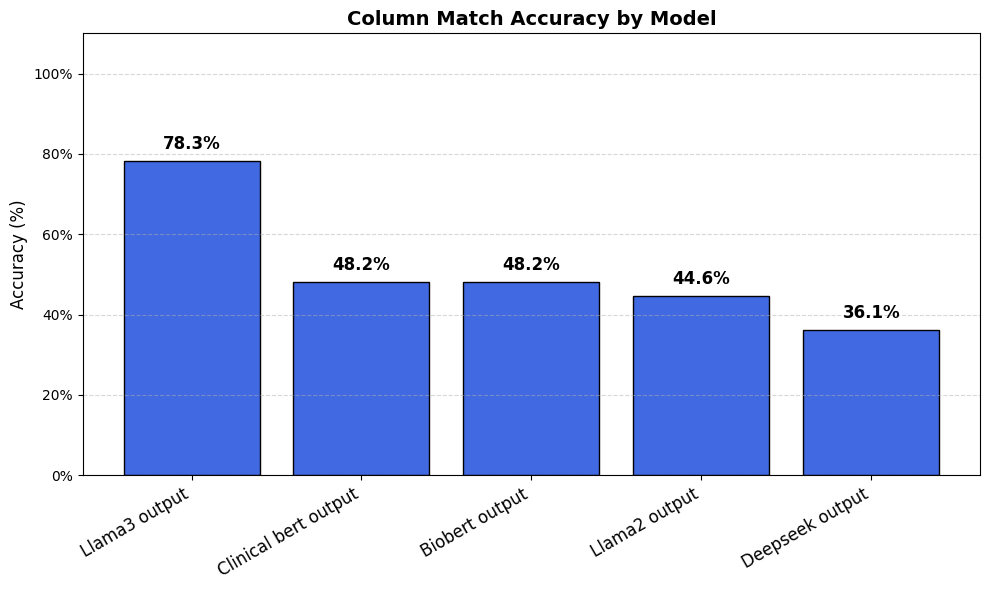

In [60]:
accuracy_viz(merged_df_val, output_list)

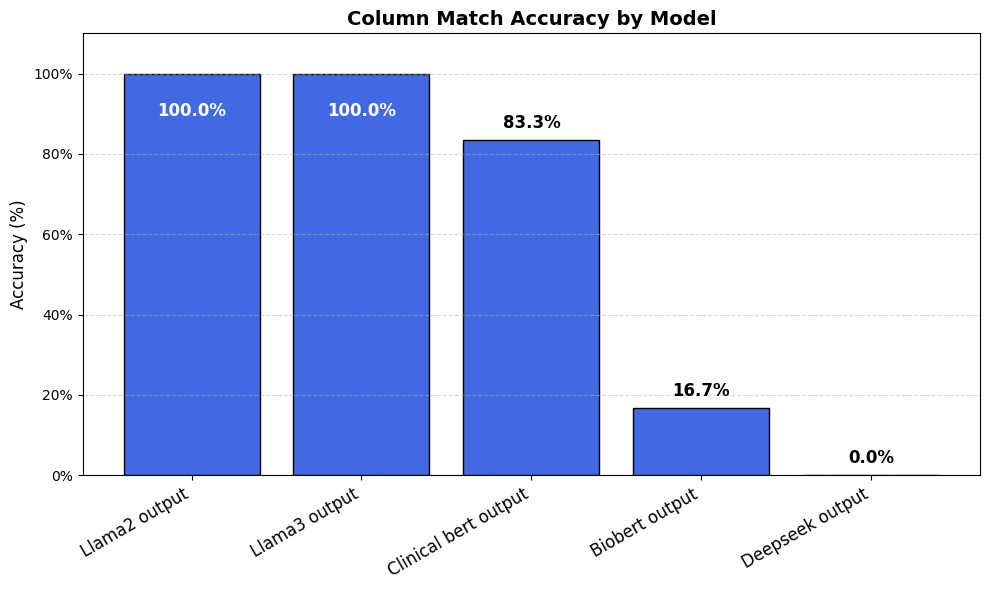

In [61]:
accuracy_viz(merged_df_val[merged_df_val['Form_Description'] == 'Physical'], output_list)

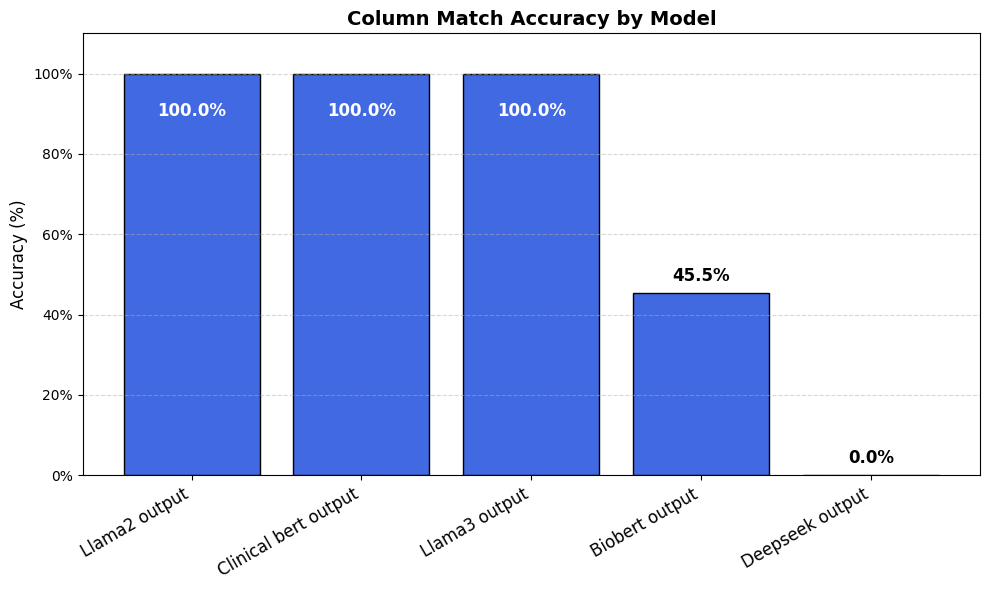

In [62]:
accuracy_viz(merged_df_val[merged_df_val['Form_Description'] == 'Medications'], output_list)

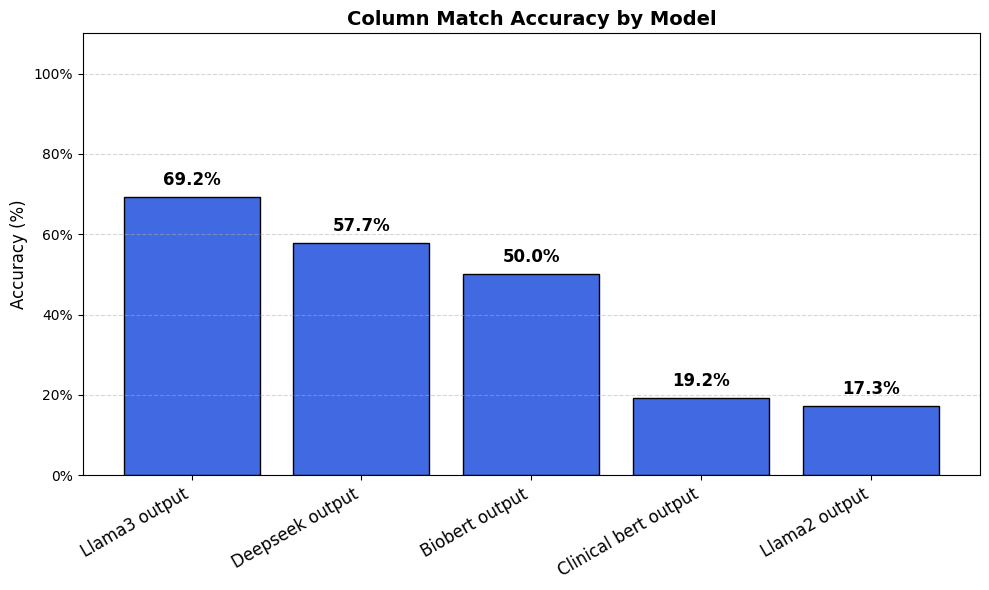

In [63]:
accuracy_viz(merged_df_val[merged_df_val['Form_Description'] == 'Clinician Diagnosis'], output_list)

In [82]:
!nvidia-smi

Tue Mar 11 19:45:23 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla V100-PCIE-32GB           On  |   00000000:88:00.0 Off |                    0 |
| N/A   29C    P0             34W /  250W |   14334MiB /  32768MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
